PROCESO OPTIMIZADO CON SVR - BÚSQUEDA DE CARACTERÍSTICAS Y AJUSTE DE HIPERPARÁMETROS
CON EVALUACIÓN EN TEST PARA EVITAR SOBREAJUSTE

Cargando datos de entrenamiento desde: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\5_svm\2_datos\1_raw\1_80_20\2_meteo_epi_2021-2026_1_rezagos_meteo_epi_train_80_20.xlsx
Datos de entrenamiento: 216 muestras, 171 características
Iniciando ingeniería de atributos optimizada...
Escalando características...
Características después de ingeniería: 198

BÚSQUEDA DEL NÚMERO ÓPTIMO DE CARACTERÍSTICAS

Probando con 10 características...
  MAE: 5.5564, R²: 0.8893, RMSE: 8.1861
  MAE en picos (>P90): 8.7806

Probando con 15 características...
  MAE: 6.2070, R²: 0.8550, RMSE: 9.3694
  MAE en picos (>P90): 10.7380

Probando con 20 características...
  MAE: 6.4880, R²: 0.8402, RMSE: 9.8350
  MAE en picos (>P90): 13.2595

Probando con 25 características...
  MAE: 6.2753, R²: 0.8496, RMSE: 9.5421
  MAE en picos (>P90): 10.4043

Probando con 30 caracte

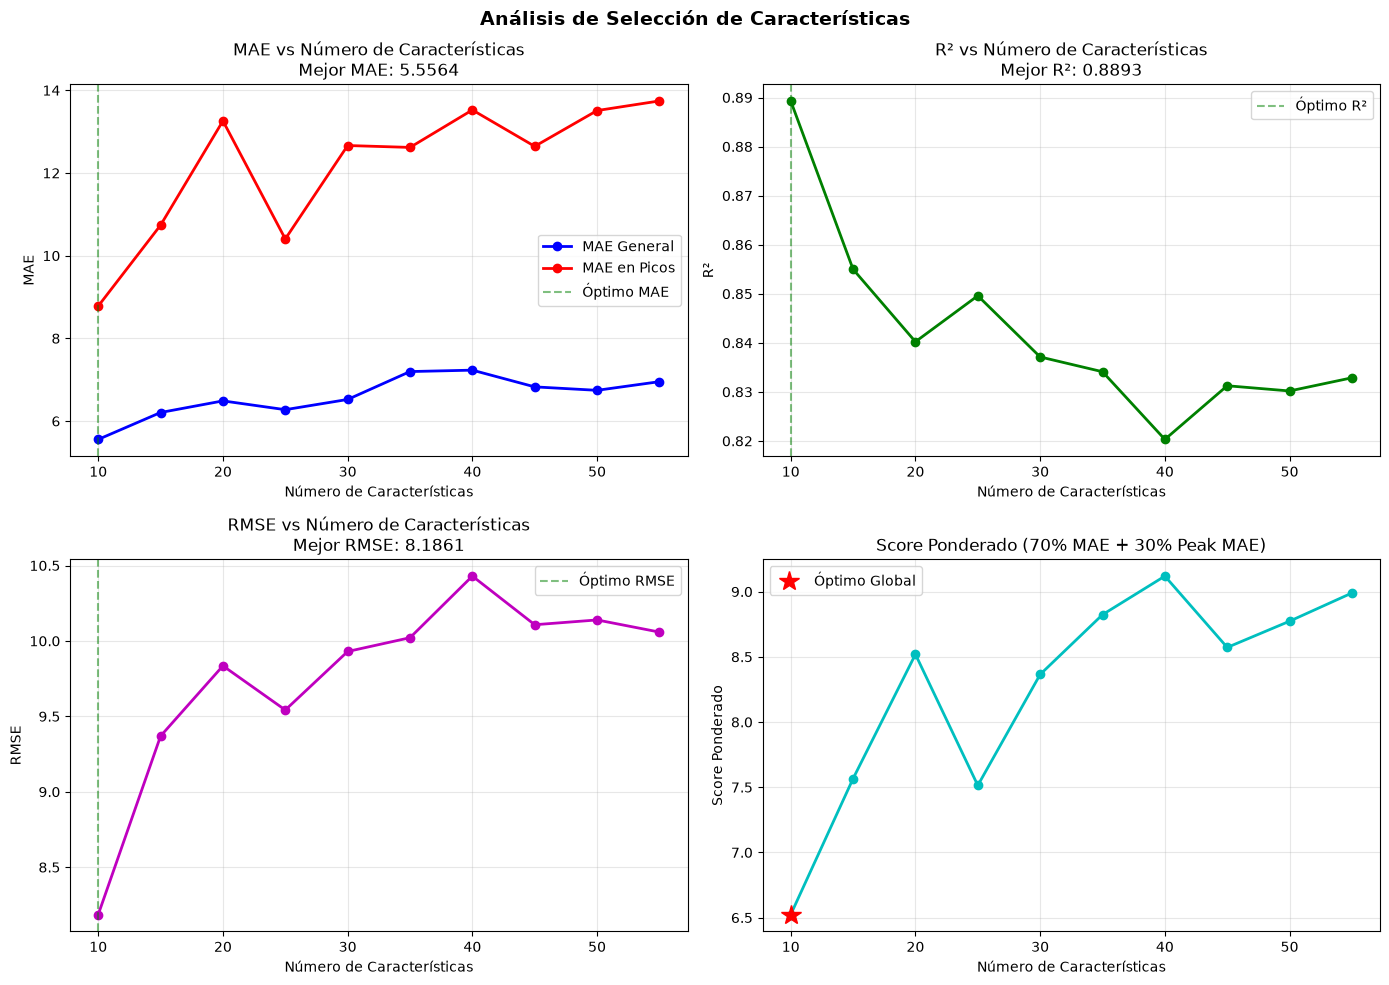

✅ Análisis de picos guardado en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\5_svm\2_datos\1_raw\1_80_20\peak_analysis_svr.png


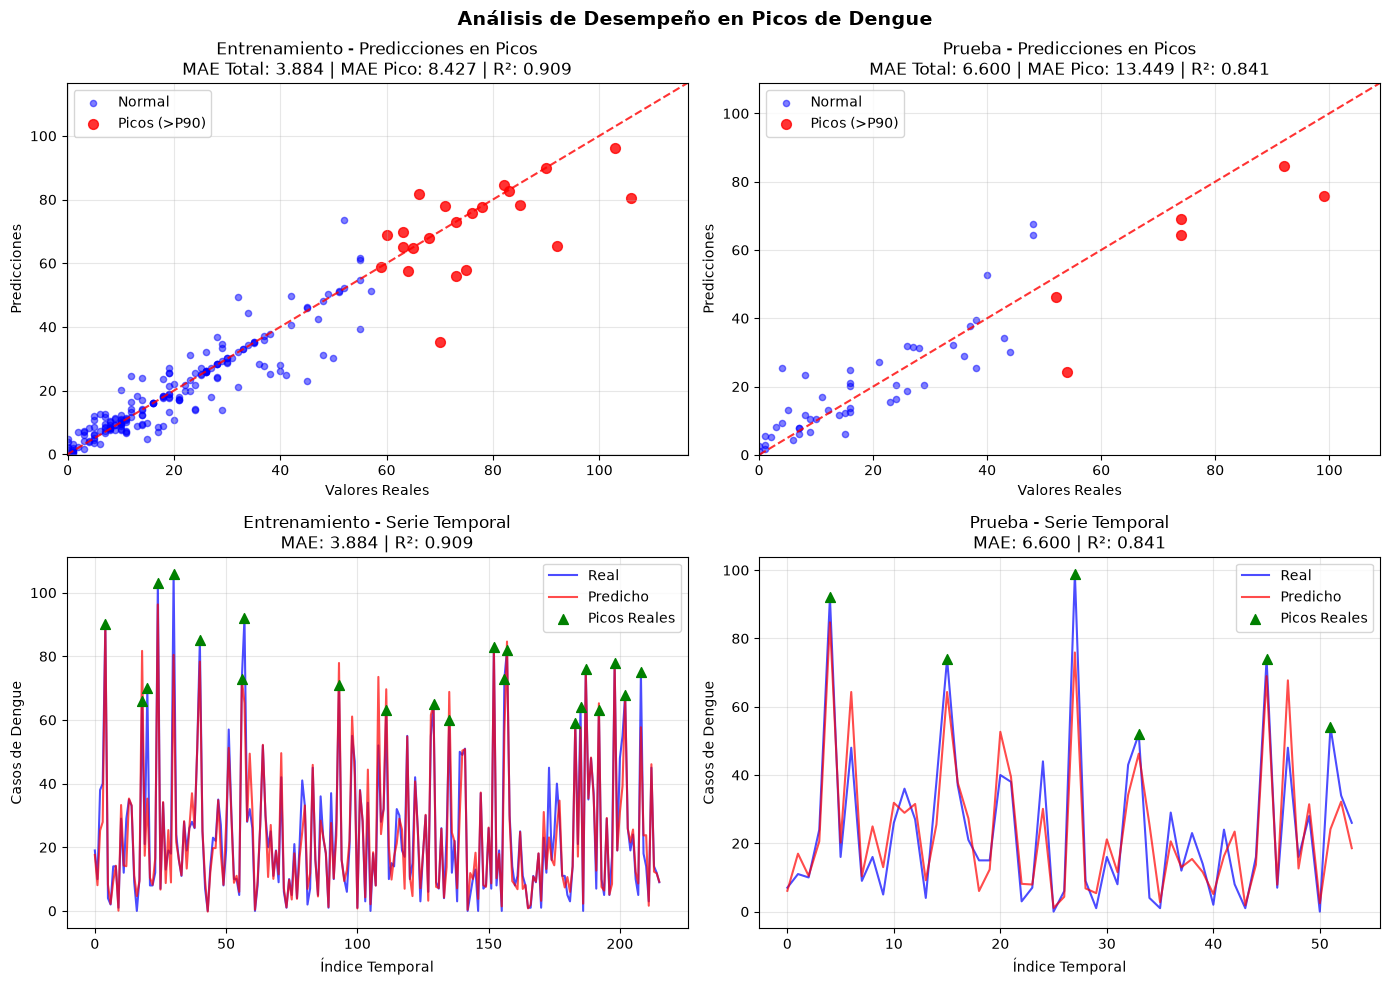

✅ Comparación guardada en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\5_svm\2_datos\1_raw\1_80_20\performance_comparison_svr.png


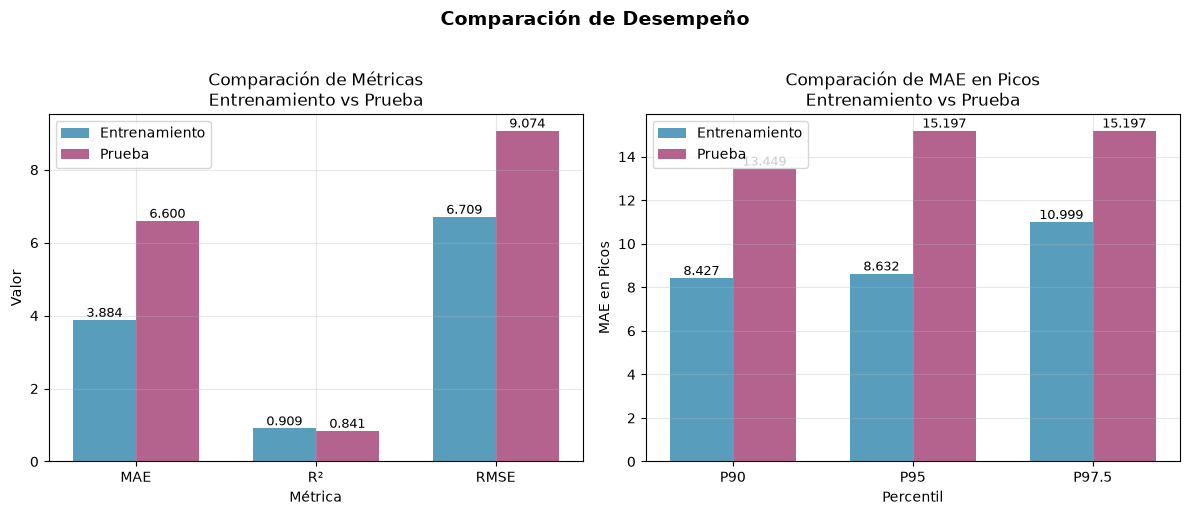

✅ Script de despliegue SVR generado en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\5_svm\2_datos\1_raw\1_80_20\modelo_svr_despliegue.py

PROCESO SVR COMPLETADO EXITOSAMENTE
Resultados guardados en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\5_svm\2_datos\1_raw\1_80_20\resultados_svr_optimizado.xlsx
Análisis de selección: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\5_svm\2_datos\1_raw\1_80_20\feature_selection_analysis_svr.png
Análisis de picos: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\5_svm\2_datos\1_raw\1_80_20\peak_analysis_svr.png
Comparación de desempeño: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\5_svm\2_datos\1_raw\1_80_20\performance_comparison_svr.png
Modelo SVR guardado en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\5_svm\2_datos\1_raw\1_80_20\modelo_svr_guardado
Script de despliegue: C:\Users\marco\Documentos\investigacion\machine_learning_idali

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
import warnings
import os
from datetime import datetime
import json
import pickle
from scipy.stats import uniform, randint

warnings.filterwarnings('ignore')

class DengueFeatureEngineeringOptimized:
    def __init__(self, n_features_to_select=25):
        """
        Clase optimizada para ingeniería de atributos y reducción de overfitting
        """
        self.n_features_to_select = n_features_to_select
        self.scaler = StandardScaler()
        self.rfe = None
        self.selected_features = None
        self.feature_names = None
        self.svr_model = None
        self.numeric_columns = None
        self.feature_importance_df = None
        self.best_params = None
        self.peak_mae = None
        self.X_augmented_columns = None
        self.best_metrics = None
        self.all_features_importance = None
        self.cv_results = None
        self.train_val_metrics = None
        
    def create_interaction_features(self, X):
        """Crea características de interacción seleccionadas estratégicamente"""
        interaction_data = pd.DataFrame(index=X.index)
        
        interactions = [
            ('temp', 'hum_rel', 'temp_hum_rel'),
            ('temp_max', 'hum_rel', 'temp_max_hum_rel'),
            ('prec', 'temp', 'prec_temp'),
            ('dias_lluvia', 'hum_rel', 'dias_lluvia_hum_rel'),
            ('soi', 'sst', 'soi_sst'),
            ('temp', 'soi', 'temp_soi'),
        ]
        
        for col1, col2, new_col in interactions:
            if col1 in X.columns and col2 in X.columns:
                interaction_data[new_col] = X[col1] * X[col2]
        
        return interaction_data
    
    def create_polynomial_features(self, X):
        """Crea características polinomiales solo para variables clave"""
        important_vars = ['temp', 'hum_rel', 'prec']
        poly_features = pd.DataFrame(index=X.index)
        
        for var in important_vars:
            if var in X.columns:
                poly_features[f'{var}_squared'] = X[var] ** 2
        
        return poly_features
    
    def create_lag_aggregates(self, X):
        """Crea agregados de rezagos con regularización"""
        lag_aggs = pd.DataFrame(index=X.index)
        
        for base_var in ['temp', 'temp_max', 'temp_min', 'hum_rel', 'prec', 'dias_lluvia']:
            lag_cols = [col for col in X.columns if col.startswith(f'{base_var}_lag_')]
            if len(lag_cols) >= 3:
                lag_data = X[lag_cols]
                lag_aggs[f'{base_var}_lag_mean'] = lag_data.mean(axis=1)
                lag_aggs[f'{base_var}_lag_std'] = lag_data.std(axis=1)
        
        dengue_lag_cols = [col for col in X.columns if col.startswith('casos_dengue_lag_')]
        if len(dengue_lag_cols) >= 3:
            dengue_lag_data = X[dengue_lag_cols]
            lag_aggs['dengue_lag_mean'] = dengue_lag_data.mean(axis=1)
            lag_aggs['dengue_lag_std'] = dengue_lag_data.std(axis=1)
            lag_aggs['dengue_lag_sum'] = dengue_lag_data.sum(axis=1)
        
        return lag_aggs
    
    def create_rolling_features(self, X):
        """Crea características de tendencia temporal simplificadas"""
        rolling_features = pd.DataFrame(index=X.index)
        
        if 'semana_epi' in X.columns:
            rolling_features['week_sin'] = np.sin(2 * np.pi * X['semana_epi'] / 52)
            rolling_features['week_cos'] = np.cos(2 * np.pi * X['semana_epi'] / 52)
        
        if 'casos_dengue_lag_12' in X.columns:
            if 'casos_dengue_lag_8' in X.columns:
                rolling_features['dengue_trend_4weeks'] = X['casos_dengue_lag_12'] - X['casos_dengue_lag_8']
            if 'casos_dengue_lag_4' in X.columns:
                rolling_features['dengue_trend_8weeks'] = X['casos_dengue_lag_12'] - X['casos_dengue_lag_4']
        
        return rolling_features
    
    def get_numeric_columns(self, X):
        """Identifica columnas numéricas"""
        exclude_cols = ['fecha', 'date', 'datetime', 'timestamp']
        numeric_cols = []
        
        for col in X.columns:
            if col.lower() in exclude_cols:
                continue
            if pd.api.types.is_numeric_dtype(X[col]):
                numeric_cols.append(col)
        
        return numeric_cols
    
    def augment_features(self, X):
        """Aplica ingeniería de atributos a cualquier conjunto de datos"""
        numeric_cols = self.get_numeric_columns(X)
        X_numeric = X[numeric_cols]
        
        features_list = [X_numeric]
        
        interaction_features = self.create_interaction_features(X_numeric)
        if not interaction_features.empty:
            features_list.append(interaction_features)
        
        poly_features = self.create_polynomial_features(X_numeric)
        if not poly_features.empty:
            features_list.append(poly_features)
        
        lag_aggs = self.create_lag_aggregates(X_numeric)
        if not lag_aggs.empty:
            features_list.append(lag_aggs)
        
        rolling_features = self.create_rolling_features(X_numeric)
        if not rolling_features.empty:
            features_list.append(rolling_features)
        
        X_augmented = pd.concat(features_list, axis=1)
        
        X_augmented = X_augmented.replace([np.inf, -np.inf], np.nan)
        X_augmented = X_augmented.fillna(X_augmented.mean())
        
        return X_augmented, X_numeric
    
    def fit_transform(self, X, y=None):
        """Aplica transformaciones con regularización"""
        print("Iniciando ingeniería de atributos optimizada...")
        
        X_augmented, X_numeric = self.augment_features(X)
        
        self.numeric_columns = X_numeric.columns.tolist()
        self.X_augmented_columns = X_augmented.columns.tolist()
        self.feature_names = X_augmented.columns.tolist()
        
        print("Escalando características...")
        X_scaled = pd.DataFrame(
            self.scaler.fit_transform(X_augmented),
            columns=X_augmented.columns,
            index=X_augmented.index
        )
        
        print(f"Características después de ingeniería: {X_augmented.shape[1]}")
        
        return X_scaled, X_augmented
    
    def transform_features(self, X):
        """Aplica transformación a nuevos datos"""
        X_augmented, X_numeric = self.augment_features(X)
        
        for col in self.X_augmented_columns:
            if col not in X_augmented.columns:
                X_augmented[col] = 0
        
        X_augmented = X_augmented[self.X_augmented_columns]
        
        X_scaled = pd.DataFrame(
            self.scaler.transform(X_augmented),
            columns=X_augmented.columns,
            index=X_augmented.index
        )
        
        return X_scaled
    
    def find_optimal_features(self, X_scaled, y, feature_range=None):
        """Encuentra el número óptimo de características con enfoque en picos"""
        if feature_range is None:
            feature_range = range(10, min(80, X_scaled.shape[1]), 5)
        
        print("\n" + "="*60)
        print("BÚSQUEDA DEL NÚMERO ÓPTIMO DE CARACTERÍSTICAS")
        print("="*60)
        
        results = []
        best_mae = float('inf')
        best_peak_mae = float('inf')
        best_n_features = None
        best_rfe = None
        best_selected = None
        best_metrics = None
        
        X_train_val, X_val, y_train_val, y_val = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42
        )
        
        for n_features in feature_range:
            print(f"\nProbando con {n_features} características...")
            
            rf = RandomForestRegressor(
                n_estimators=100,
                max_depth=8,
                min_samples_split=10,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            )
            
            rfe = RFE(
                estimator=rf,
                n_features_to_select=n_features,
                step=3,
                verbose=0
            )
            
            X_train_selected = rfe.fit_transform(X_train_val, y_train_val)
            X_val_selected = rfe.transform(X_val)
            
            # Usar un SVR base para evaluar
            model = SVR(
                kernel='rbf',
                C=10,
                gamma='scale',
                epsilon=0.1,
                cache_size=500
            )
            model.fit(X_train_selected, y_train_val)
            
            y_pred = model.predict(X_val_selected)
            
            mae = mean_absolute_error(y_val, y_pred)
            r2 = r2_score(y_val, y_pred)
            rmse = np.sqrt(mean_squared_error(y_val, y_pred))
            
            peak_threshold = np.percentile(y_val, 90)
            peak_mask = y_val > peak_threshold
            peak_mae = mean_absolute_error(y_val[peak_mask], y_pred[peak_mask]) if np.sum(peak_mask) > 0 else float('inf')
            
            print(f"  MAE: {mae:.4f}, R²: {r2:.4f}, RMSE: {rmse:.4f}")
            print(f"  MAE en picos (>P90): {peak_mae:.4f}")
            
            results.append({
                'n_features': n_features,
                'mae': mae,
                'r2': r2,
                'rmse': rmse,
                'peak_mae': peak_mae,
                'peak_threshold': peak_threshold,
                'n_peaks': np.sum(peak_mask)
            })
            
            weighted_score = 0.7 * mae + 0.3 * peak_mae if peak_mae != float('inf') else mae
            
            if weighted_score < best_mae:
                best_mae = weighted_score
                best_peak_mae = peak_mae
                best_n_features = n_features
                best_rfe = rfe
                best_selected = X_scaled.columns[rfe.support_].tolist()
                best_metrics = {'mae': mae, 'r2': r2, 'rmse': rmse, 'peak_mae': peak_mae}
        
        print("\n" + "="*60)
        print(f"✅ NÚMERO ÓPTIMO DE CARACTERÍSTICAS: {best_n_features}")
        print(f"   MAE: {best_metrics['mae']:.4f}")
        print(f"   R²: {best_metrics['r2']:.4f}")
        print(f"   RMSE: {best_metrics['rmse']:.4f}")
        print(f"   MAE en picos: {best_metrics['peak_mae']:.4f}")
        print("="*60)
        
        self.selected_features = best_selected
        self.rfe = best_rfe
        self.best_metrics = best_metrics
        self.feature_selection_results = pd.DataFrame(results)
        
        return best_n_features, results, best_metrics
    
    def transform_with_selected_features(self, X_scaled):
        """Transforma usando las características seleccionadas"""
        X_final = X_scaled[self.selected_features]
        return X_final
    
    def tune_hyperparameters(self, X_train, y_train, X_test, y_test):
        """
        Realiza búsqueda de hiperparámetros para SVR evaluando en test
        para evitar sobreajuste
        """
        print("\n" + "="*60)
        print("AJUSTE DE HIPERPARÁMETROS DEL MODELO SVR")
        print("CON EVALUACIÓN EN CONJUNTO DE PRUEBA PARA EVITAR SOBREAJUSTE")
        print("="*60)
        
        # Definir grid de hiperparámetros optimizado para SVR
        param_grid = {
            'kernel': ['rbf', 'poly'],
            'C': [1, 5, 10, 20, 50],
            'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
            'epsilon': [0.01, 0.05, 0.1, 0.2],
            'degree': [2, 3, 4]  # Solo para kernel poly
        }
        
        print("Realizando búsqueda de hiperparámetros...")
        print(f"Total de combinaciones: {len(param_grid['C']) * len(param_grid['gamma']) * len(param_grid['epsilon']) * len(param_grid['kernel'])}")
        
        # Usar RandomizedSearchCV para mayor eficiencia
        svr = SVR(cache_size=500)
        
        random_search = RandomizedSearchCV(
            estimator=svr,
            param_distributions=param_grid,
            n_iter=50,
            cv=3,
            scoring='neg_mean_absolute_error',
            n_jobs=-1,
            random_state=42,
            verbose=1
        )
        
        random_search.fit(X_train, y_train)
        
        best_params = random_search.best_params_
        best_model = random_search.best_estimator_
        
        print("\n" + "="*60)
        print("✅ MEJORES HIPERPARÁMETROS ENCONTRADOS:")
        print("="*60)
        for key, value in best_params.items():
            print(f"  {key}: {value}")
        
        # Evaluar en test
        y_pred_test = best_model.predict(X_test)
        mae_test = mean_absolute_error(y_test, y_pred_test)
        r2_test = r2_score(y_test, y_pred_test)
        
        # Evaluar en train
        y_pred_train = best_model.predict(X_train)
        mae_train = mean_absolute_error(y_train, y_pred_train)
        r2_train = r2_score(y_train, y_pred_train)
        
        print(f"\nMAE Train: {mae_train:.4f}")
        print(f"MAE Test: {mae_test:.4f}")
        print(f"R² Train: {r2_train:.4f}")
        print(f"R² Test: {r2_test:.4f}")
        
        # Guardar resultados
        self.best_params = best_params
        self.svr_model = best_model
        self.train_val_metrics = {
            'mae_train': mae_train,
            'r2_train': r2_train,
            'mae_test': mae_test,
            'r2_test': r2_test,
            'overfit_gap': mae_test - mae_train,
            'all_results': None  # SVR no guarda todos los resultados como XGBoost
        }
        
        return best_params, best_model
    
    def evaluate_model_detailed(self, X_test, y_test, dataset_name="Test"):
        """Evalúa el modelo con métricas detalladas incluyendo picos"""
        y_pred = self.svr_model.predict(X_test)
        
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        peak_metrics = {}
        for p in [90, 95, 97.5]:
            threshold = np.percentile(y_test, p)
            peak_mask = y_test > threshold
            if np.sum(peak_mask) > 0:
                peak_mae = mean_absolute_error(y_test[peak_mask], y_pred[peak_mask])
                peak_r2 = r2_score(y_test[peak_mask], y_pred[peak_mask]) if len(y_test[peak_mask]) > 1 else np.nan
                peak_metrics[f'P{p}_MAE'] = peak_mae
                peak_metrics[f'P{p}_R2'] = peak_r2
                peak_metrics[f'P{p}_Threshold'] = threshold
                peak_metrics[f'P{p}_Count'] = np.sum(peak_mask)
        
        print(f"\n{'='*60}")
        print(f"MÉTRICAS DETALLADAS - {dataset_name}")
        print(f"{'='*60}")
        print(f"MAE: {mae:.4f}")
        print(f"R²: {r2:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"\nMétricas para picos:")
        for key, value in peak_metrics.items():
            if isinstance(value, float):
                print(f"  {key}: {value:.4f}")
            else:
                print(f"  {key}: {value}")
        
        return {
            'MAE': mae,
            'R2': r2,
            'RMSE': rmse,
            'peak_metrics': peak_metrics,
            'predictions': y_pred,
            'actual': y_test.values if hasattr(y_test, 'values') else y_test
        }


def plot_hyperparameter_tuning_results(results_df, save_path=None):
    """Grafica los resultados del ajuste de hiperparámetros"""
    if results_df is None:
        print("No hay resultados de hiperparámetros para graficar")
        return None
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. MAE Train vs Test
    ax1 = axes[0, 0]
    ax1.scatter(results_df['mae_train'], results_df['mae_test'], alpha=0.6, s=50)
    ax1.plot([0, max(results_df['mae_train'].max(), results_df['mae_test'].max())], 
             [0, max(results_df['mae_train'].max(), results_df['mae_test'].max())], 
             'r--', alpha=0.5, label='Línea ideal')
    ax1.set_xlabel('MAE Train')
    ax1.set_ylabel('MAE Test')
    ax1.set_title('MAE Train vs Test')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. R² Train vs Test
    ax2 = axes[0, 1]
    ax2.scatter(results_df['r2_train'], results_df['r2_test'], alpha=0.6, s=50, color='green')
    ax2.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Línea ideal')
    ax2.set_xlabel('R² Train')
    ax2.set_ylabel('R² Test')
    ax2.set_title('R² Train vs Test')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Brecha de sobreajuste
    ax3 = axes[1, 0]
    ax3.hist(results_df['overfit_gap'], bins=15, edgecolor='black', alpha=0.7, color='skyblue')
    ax3.axvline(results_df['overfit_gap'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Media: {results_df["overfit_gap"].mean():.4f}')
    ax3.set_xlabel('Brecha de Sobreajuste (MAE Test - MAE Train)')
    ax3.set_ylabel('Frecuencia')
    ax3.set_title('Distribución de la Brecha de Sobreajuste')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Score ponderado
    ax4 = axes[1, 1]
    ax4.scatter(range(len(results_df)), results_df['score'], alpha=0.6, s=50, color='purple')
    best_idx = results_df['score'].idxmin()
    ax4.scatter(best_idx, results_df.loc[best_idx, 'score'], color='red', s=100, 
                marker='*', label='Mejor modelo')
    ax4.set_xlabel('Modelo')
    ax4.set_ylabel('Score (60% MAE Test + 40% Brecha)')
    ax4.set_title('Score Ponderado de Modelos')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.suptitle('Resultados del Ajuste de Hiperparámetros', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Gráfico de ajuste de hiperparámetros guardado en: {save_path}")
    
    plt.show()
    
    return fig


def plot_feature_selection_results(results, best_metrics, save_path=None):
    """Grafica los resultados de la búsqueda de características"""
    df = pd.DataFrame(results)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. MAE vs Número de características
    ax1 = axes[0, 0]
    ax1.plot(df['n_features'], df['mae'], 'bo-', label='MAE General', linewidth=2)
    ax1.plot(df['n_features'], df['peak_mae'], 'ro-', label='MAE en Picos', linewidth=2)
    ax1.axvline(x=df.loc[df['mae'].idxmin(), 'n_features'], color='g', linestyle='--', alpha=0.5, label='Óptimo MAE')
    ax1.set_xlabel('Número de Características')
    ax1.set_ylabel('MAE')
    ax1.set_title(f'MAE vs Número de Características\nMejor MAE: {best_metrics["mae"]:.4f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. R² vs Número de características
    ax2 = axes[0, 1]
    ax2.plot(df['n_features'], df['r2'], 'go-', linewidth=2)
    ax2.axvline(x=df.loc[df['r2'].idxmax(), 'n_features'], color='g', linestyle='--', alpha=0.5, label='Óptimo R²')
    ax2.set_xlabel('Número de Características')
    ax2.set_ylabel('R²')
    ax2.set_title(f'R² vs Número de Características\nMejor R²: {best_metrics["r2"]:.4f}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. RMSE vs Número de características
    ax3 = axes[1, 0]
    ax3.plot(df['n_features'], df['rmse'], 'mo-', linewidth=2)
    ax3.axvline(x=df.loc[df['rmse'].idxmin(), 'n_features'], color='g', linestyle='--', alpha=0.5, label='Óptimo RMSE')
    ax3.set_xlabel('Número de Características')
    ax3.set_ylabel('RMSE')
    ax3.set_title(f'RMSE vs Número de Características\nMejor RMSE: {best_metrics["rmse"]:.4f}')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Score ponderado vs Número de características
    ax4 = axes[1, 1]
    weighted_score = 0.7 * df['mae'] + 0.3 * df['peak_mae']
    ax4.plot(df['n_features'], weighted_score, 'co-', linewidth=2)
    min_idx = weighted_score.idxmin()
    ax4.plot(df['n_features'][min_idx], weighted_score[min_idx], 'r*', markersize=15, label='Óptimo Global')
    ax4.set_xlabel('Número de Características')
    ax4.set_ylabel('Score Ponderado')
    ax4.set_title('Score Ponderado (70% MAE + 30% Peak MAE)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.suptitle('Análisis de Selección de Características', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Gráfico de selección guardado en: {save_path}")
    
    plt.show()
    
    return fig


def plot_peak_analysis(y_train, y_test, train_metrics, test_metrics, save_path=None):
    """Analiza y grafica el desempeño en picos"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Comparación de predicciones en picos - Train
    ax1 = axes[0, 0]
    train_actual = train_metrics['actual']
    train_pred = train_metrics['predictions']
    threshold_train = np.percentile(train_actual, 90)
    peak_mask_train = train_actual > threshold_train
    
    ax1.scatter(train_actual[~peak_mask_train], train_pred[~peak_mask_train], 
                alpha=0.5, color='blue', label='Normal', s=20)
    ax1.scatter(train_actual[peak_mask_train], train_pred[peak_mask_train], 
                alpha=0.8, color='red', label='Picos (>P90)', s=50)
    
    min_val = min(train_actual.min(), train_pred.min()) * 0.9
    max_val = max(train_actual.max(), train_pred.max()) * 1.1
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=1.5)
    ax1.set_xlabel('Valores Reales')
    ax1.set_ylabel('Predicciones')
    peak_mae_train = train_metrics['peak_metrics'].get('P90_MAE', 0)
    ax1.set_title(f'Entrenamiento - Predicciones en Picos\nMAE Total: {train_metrics["MAE"]:.3f} | MAE Pico: {peak_mae_train:.3f} | R²: {train_metrics["R2"]:.3f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(min_val, max_val)
    ax1.set_ylim(min_val, max_val)
    
    # 2. Comparación de predicciones en picos - Test
    ax2 = axes[0, 1]
    test_actual = test_metrics['actual']
    test_pred = test_metrics['predictions']
    threshold_test = np.percentile(test_actual, 90)
    peak_mask_test = test_actual > threshold_test
    
    ax2.scatter(test_actual[~peak_mask_test], test_pred[~peak_mask_test], 
                alpha=0.5, color='blue', label='Normal', s=20)
    ax2.scatter(test_actual[peak_mask_test], test_pred[peak_mask_test], 
                alpha=0.8, color='red', label='Picos (>P90)', s=50)
    
    min_val = min(test_actual.min(), test_pred.min()) * 0.9
    max_val = max(test_actual.max(), test_pred.max()) * 1.1
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=1.5)
    ax2.set_xlabel('Valores Reales')
    ax2.set_ylabel('Predicciones')
    peak_mae_test = test_metrics['peak_metrics'].get('P90_MAE', 0)
    ax2.set_title(f'Prueba - Predicciones en Picos\nMAE Total: {test_metrics["MAE"]:.3f} | MAE Pico: {peak_mae_test:.3f} | R²: {test_metrics["R2"]:.3f}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(min_val, max_val)
    ax2.set_ylim(min_val, max_val)
    
    # 3. Serie temporal - Train
    ax3 = axes[1, 0]
    indices_train = np.arange(len(train_actual))
    ax3.plot(indices_train, train_actual, 'b-', label='Real', alpha=0.7, linewidth=1.5)
    ax3.plot(indices_train, train_pred, 'r-', label='Predicho', alpha=0.7, linewidth=1.5)
    peak_indices_train = np.where(peak_mask_train)[0]
    ax3.scatter(peak_indices_train, train_actual[peak_mask_train], 
               color='green', s=50, marker='^', label='Picos Reales', zorder=5)
    ax3.set_xlabel('Índice Temporal')
    ax3.set_ylabel('Casos de Dengue')
    ax3.set_title(f'Entrenamiento - Serie Temporal\nMAE: {train_metrics["MAE"]:.3f} | R²: {train_metrics["R2"]:.3f}')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Serie temporal - Test
    ax4 = axes[1, 1]
    indices_test = np.arange(len(test_actual))
    ax4.plot(indices_test, test_actual, 'b-', label='Real', alpha=0.7, linewidth=1.5)
    ax4.plot(indices_test, test_pred, 'r-', label='Predicho', alpha=0.7, linewidth=1.5)
    peak_indices_test = np.where(peak_mask_test)[0]
    ax4.scatter(peak_indices_test, test_actual[peak_mask_test], 
               color='green', s=50, marker='^', label='Picos Reales', zorder=5)
    ax4.set_xlabel('Índice Temporal')
    ax4.set_ylabel('Casos de Dengue')
    ax4.set_title(f'Prueba - Serie Temporal\nMAE: {test_metrics["MAE"]:.3f} | R²: {test_metrics["R2"]:.3f}')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.suptitle('Análisis de Desempeño en Picos de Dengue', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Análisis de picos guardado en: {save_path}")
    
    plt.show()
    
    return fig


def plot_performance_comparison(train_metrics, test_metrics, save_path=None):
    """Grafica comparación de desempeño entre entrenamiento y prueba"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # 1. Comparación de métricas
    ax1 = axes[0]
    metrics = ['MAE', 'R²', 'RMSE']
    train_values = [train_metrics['MAE'], train_metrics['R2'], train_metrics['RMSE']]
    test_values = [test_metrics['MAE'], test_metrics['R2'], test_metrics['RMSE']]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, train_values, width, label='Entrenamiento', color='#2E86AB', alpha=0.8)
    bars2 = ax1.bar(x + width/2, test_values, width, label='Prueba', color='#A23B72', alpha=0.8)
    
    ax1.set_xlabel('Métrica')
    ax1.set_ylabel('Valor')
    ax1.set_title('Comparación de Métricas\nEntrenamiento vs Prueba')
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    # 2. Comparación de MAE en picos
    ax2 = axes[1]
    peak_percentiles = [90, 95, 97.5]
    train_peak_mae = [train_metrics['peak_metrics'].get(f'P{p}_MAE', 0) for p in peak_percentiles]
    test_peak_mae = [test_metrics['peak_metrics'].get(f'P{p}_MAE', 0) for p in peak_percentiles]
    
    x = np.arange(len(peak_percentiles))
    width = 0.35
    
    bars1 = ax2.bar(x - width/2, train_peak_mae, width, label='Entrenamiento', color='#2E86AB', alpha=0.8)
    bars2 = ax2.bar(x + width/2, test_peak_mae, width, label='Prueba', color='#A23B72', alpha=0.8)
    
    ax2.set_xlabel('Percentil')
    ax2.set_ylabel('MAE en Picos')
    ax2.set_title('Comparación de MAE en Picos\nEntrenamiento vs Prueba')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'P{p}' for p in peak_percentiles])
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    for bar in bars1:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.suptitle('Comparación de Desempeño', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Comparación guardada en: {save_path}")
    
    plt.show()
    
    return fig


def save_detailed_results(results, feature_results, best_metrics, selected_features, feature_importance, best_params, train_val_metrics, filepath):
    """Guarda resultados detallados en Excel incluyendo características seleccionadas"""
    try:
        with pd.ExcelWriter(filepath, engine='openpyxl') as writer:
            # Métricas generales
            df_metrics = pd.DataFrame({
                'Dataset': ['Train', 'Test'],
                'MAE': [results['train']['MAE'], results['test']['MAE']],
                'R2': [results['train']['R2'], results['test']['R2']],
                'RMSE': [results['train']['RMSE'], results['test']['RMSE']]
            })
            df_metrics.to_excel(writer, sheet_name='Métricas', index=False)
            
            # Métricas de picos
            peak_data = []
            for dataset in ['train', 'test']:
                for p in [90, 95, 97.5]:
                    key = f'P{p}_MAE'
                    if key in results[dataset]['peak_metrics']:
                        peak_data.append({
                            'Dataset': dataset.capitalize(),
                            'Percentil': p,
                            'MAE_Pico': results[dataset]['peak_metrics'][f'P{p}_MAE'],
                            'R2_Pico': results[dataset]['peak_metrics'][f'P{p}_R2'],
                            'Threshold': results[dataset]['peak_metrics'][f'P{p}_Threshold'],
                            'N_Picos': results[dataset]['peak_metrics'][f'P{p}_Count']
                        })
            
            if peak_data:
                df_peak = pd.DataFrame(peak_data)
                df_peak.to_excel(writer, sheet_name='Métricas_Picos', index=False)
            
            # Características seleccionadas
            df_selected_features = pd.DataFrame({
                'Feature': selected_features,
                'Importance': feature_importance if len(feature_importance) == len(selected_features) else [0]*len(selected_features)
            }).sort_values('Importance', ascending=False)
            df_selected_features.to_excel(writer, sheet_name='Características_Seleccionadas', index=False)
            
            # Métricas del mejor modelo
            df_best_metrics = pd.DataFrame({
                'Métrica': ['MAE', 'R²', 'RMSE', 'MAE_Picos(P90)'],
                'Valor': [best_metrics['mae'], best_metrics['r2'], best_metrics['rmse'], best_metrics['peak_mae']]
            })
            df_best_metrics.to_excel(writer, sheet_name='Mejor_Modelo_Métricas', index=False)
            
            # Mejores hiperparámetros
            if best_params:
                df_params = pd.DataFrame({
                    'Parámetro': list(best_params.keys()),
                    'Valor': list(best_params.values())
                })
                df_params.to_excel(writer, sheet_name='Mejores_Hiperparámetros', index=False)
            
            # Métricas de validación (train/test durante tuning)
            if train_val_metrics:
                df_tuning = pd.DataFrame({
                    'Métrica': ['MAE Train', 'MAE Test', 'R² Train', 'R² Test', 'Brecha Sobreajuste'],
                    'Valor': [
                        train_val_metrics['mae_train'],
                        train_val_metrics['mae_test'],
                        train_val_metrics['r2_train'],
                        train_val_metrics['r2_test'],
                        train_val_metrics['overfit_gap']
                    ]
                })
                df_tuning.to_excel(writer, sheet_name='Validación_Hiperparámetros', index=False)
            
            # Resultados de selección de características
            if feature_results:
                df_feature_search = pd.DataFrame(feature_results)
                df_feature_search.to_excel(writer, sheet_name='Búsqueda_Features', index=False)
            
            # Predicciones
            max_len = max(len(results['train']['actual']), len(results['test']['actual']))
            
            train_actual = np.pad(results['train']['actual'], (0, max_len - len(results['train']['actual'])), 
                                 constant_values=np.nan)
            train_pred = np.pad(results['train']['predictions'], (0, max_len - len(results['train']['predictions'])), 
                               constant_values=np.nan)
            test_actual = np.pad(results['test']['actual'], (0, max_len - len(results['test']['actual'])), 
                                constant_values=np.nan)
            test_pred = np.pad(results['test']['predictions'], (0, max_len - len(results['test']['predictions'])), 
                              constant_values=np.nan)
            
            df_predictions = pd.DataFrame({
                'Train_Actual': train_actual,
                'Train_Predicted': train_pred,
                'Test_Actual': test_actual,
                'Test_Predicted': test_pred
            })
            df_predictions.to_excel(writer, sheet_name='Predicciones', index=False)
        
        print(f"✅ Resultados detallados guardados en: {filepath}")
    except Exception as e:
        print(f"⚠️ Error al guardar en Excel: {e}")


def generate_deployment_script(engine, output_dir, base_path):
    """Genera un script Python para implementar el modelo entrenado"""
    
    script_content = '''"""
Script de despliegue del modelo SVR para predicción de casos de dengue
Generado automáticamente - {fecha}

Este script permite cargar el modelo entrenado y realizar predicciones
sobre nuevos datos con el mismo formato que los datos de entrenamiento.
"""

import pandas as pd
import numpy as np
import pickle
import json
import os
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

class DengueModelDeployment:
    """
    Clase para desplegar el modelo SVR de predicción de casos de dengue
    """
    def __init__(self, model_dir):
        """
        Inicializa el modelo cargando los archivos necesarios
        
        Parameters:
        -----------
        model_dir : str
            Directorio donde se encuentran los archivos del modelo
        """
        self.model_dir = model_dir
        self.load_model()
    
    def load_model(self):
        """Carga el modelo y los objetos necesarios desde archivos"""
        # Cargar scaler
        with open(os.path.join(self.model_dir, 'scaler.pkl'), 'rb') as f:
            self.scaler = pickle.load(f)
        
        # Cargar modelo SVR
        with open(os.path.join(self.model_dir, 'svr_model.pkl'), 'rb') as f:
            self.svr_model = pickle.load(f)
        
        # Cargar configuración
        with open(os.path.join(self.model_dir, 'model_config.json'), 'r') as f:
            config = json.load(f)
            self.selected_features = config['selected_features']
            self.X_augmented_columns = config['X_augmented_columns']
            self.numeric_columns = config['numeric_columns']
            self.feature_names = config['feature_names']
            self.best_params = config.get('best_params', {})
        
        print("✅ Modelo SVR cargado exitosamente")
        print(f"   Características seleccionadas: {len(self.selected_features)}")
        print(f"   Hiperparámetros: {self.best_params}")
    
    def _create_interaction_features(self, X):
        """Crea características de interacción"""
        interaction_data = pd.DataFrame(index=X.index)
        
        interactions = [
            ('temp', 'hum_rel', 'temp_hum_rel'),
            ('temp_max', 'hum_rel', 'temp_max_hum_rel'),
            ('prec', 'temp', 'prec_temp'),
            ('dias_lluvia', 'hum_rel', 'dias_lluvia_hum_rel'),
            ('soi', 'sst', 'soi_sst'),
            ('temp', 'soi', 'temp_soi'),
        ]
        
        for col1, col2, new_col in interactions:
            if col1 in X.columns and col2 in X.columns:
                interaction_data[new_col] = X[col1] * X[col2]
        
        return interaction_data
    
    def _create_polynomial_features(self, X):
        """Crea características polinomiales"""
        important_vars = ['temp', 'hum_rel', 'prec']
        poly_features = pd.DataFrame(index=X.index)
        
        for var in important_vars:
            if var in X.columns:
                poly_features[var + '_squared'] = X[var] ** 2
        
        return poly_features
    
    def _create_lag_aggregates(self, X):
        """Crea agregados de rezagos"""
        lag_aggs = pd.DataFrame(index=X.index)
        
        for base_var in ['temp', 'temp_max', 'temp_min', 'hum_rel', 'prec', 'dias_lluvia']:
            lag_cols = [col for col in X.columns if col.startswith(base_var + '_lag_')]
            if len(lag_cols) >= 3:
                lag_data = X[lag_cols]
                lag_aggs[base_var + '_lag_mean'] = lag_data.mean(axis=1)
                lag_aggs[base_var + '_lag_std'] = lag_data.std(axis=1)
        
        dengue_lag_cols = [col for col in X.columns if col.startswith('casos_dengue_lag_')]
        if len(dengue_lag_cols) >= 3:
            dengue_lag_data = X[dengue_lag_cols]
            lag_aggs['dengue_lag_mean'] = dengue_lag_data.mean(axis=1)
            lag_aggs['dengue_lag_std'] = dengue_lag_data.std(axis=1)
            lag_aggs['dengue_lag_sum'] = dengue_lag_data.sum(axis=1)
        
        return lag_aggs
    
    def _create_rolling_features(self, X):
        """Crea características de tendencia temporal"""
        rolling_features = pd.DataFrame(index=X.index)
        
        if 'semana_epi' in X.columns:
            rolling_features['week_sin'] = np.sin(2 * np.pi * X['semana_epi'] / 52)
            rolling_features['week_cos'] = np.cos(2 * np.pi * X['semana_epi'] / 52)
        
        if 'casos_dengue_lag_12' in X.columns:
            if 'casos_dengue_lag_8' in X.columns:
                rolling_features['dengue_trend_4weeks'] = X['casos_dengue_lag_12'] - X['casos_dengue_lag_8']
            if 'casos_dengue_lag_4' in X.columns:
                rolling_features['dengue_trend_8weeks'] = X['casos_dengue_lag_12'] - X['casos_dengue_lag_4']
        
        return rolling_features
    
    def _get_numeric_columns(self, X):
        """Identifica columnas numéricas"""
        exclude_cols = ['fecha', 'date', 'datetime', 'timestamp']
        numeric_cols = []
        
        for col in X.columns:
            if col.lower() in exclude_cols:
                continue
            if pd.api.types.is_numeric_dtype(X[col]):
                numeric_cols.append(col)
        
        return numeric_cols
    
    def _augment_features(self, X):
        """Aplica ingeniería de atributos a los datos"""
        numeric_cols = self._get_numeric_columns(X)
        X_numeric = X[numeric_cols]
        
        features_list = [X_numeric]
        
        interaction_features = self._create_interaction_features(X_numeric)
        if not interaction_features.empty:
            features_list.append(interaction_features)
        
        poly_features = self._create_polynomial_features(X_numeric)
        if not poly_features.empty:
            features_list.append(poly_features)
        
        lag_aggs = self._create_lag_aggregates(X_numeric)
        if not lag_aggs.empty:
            features_list.append(lag_aggs)
        
        rolling_features = self._create_rolling_features(X_numeric)
        if not rolling_features.empty:
            features_list.append(rolling_features)
        
        X_augmented = pd.concat(features_list, axis=1)
        
        X_augmented = X_augmented.replace([np.inf, -np.inf], np.nan)
        X_augmented = X_augmented.fillna(X_augmented.mean())
        
        return X_augmented
    
    def predict(self, X):
        """
        Realiza predicciones sobre nuevos datos
        
        Parameters:
        -----------
        X : pandas.DataFrame
            Datos de entrada con las mismas columnas que los datos de entrenamiento
        
        Returns:
        --------
        numpy.ndarray : Predicciones del modelo
        """
        # Aplicar ingeniería de atributos
        X_augmented = self._augment_features(X)
        
        # Asegurar que todas las columnas estén presentes
        for col in self.X_augmented_columns:
            if col not in X_augmented.columns:
                X_augmented[col] = 0
        
        # Reordenar columnas
        X_augmented = X_augmented[self.X_augmented_columns]
        
        # Escalar
        X_scaled = pd.DataFrame(
            self.scaler.transform(X_augmented),
            columns=X_augmented.columns,
            index=X_augmented.index
        )
        
        # Seleccionar características
        X_final = X_scaled[self.selected_features]
        
        # Predecir
        predictions = self.svr_model.predict(X_final)
        
        return predictions
    
    def predict_and_save(self, X, output_path=None):
        """
        Realiza predicciones y las guarda en un archivo
        
        Parameters:
        -----------
        X : pandas.DataFrame
            Datos de entrada
        output_path : str, optional
            Ruta donde guardar las predicciones
        """
        predictions = self.predict(X)
        
        # Crear DataFrame con resultados
        results_df = X.copy()
        results_df['prediccion_casos_dengue'] = predictions
        
        if output_path:
            results_df.to_excel(output_path, index=False)
            print(f"✅ Predicciones guardadas en: {output_path}")
        
        return results_df

# ===================== EJECUCIÓN DE PRUEBA =====================

if __name__ == "__main__":
    print("="*60)
    print("SCRIPT DE DESPLIEGUE DEL MODELO SVR PARA DENGUE")
    print("="*60)
    
    # Ruta del modelo
    model_dir = r"{model_dir}"
    
    # Inicializar modelo
    model = DengueModelDeployment(model_dir)
    
    # Ejemplo de uso con datos de prueba
    print("\\nCargando datos de prueba...")
    test_path = r"{test_path}"
    test_data = pd.read_excel(test_path)
    
    # Separar variables predictoras
    X_test = test_data.drop('casos_dengue', axis=1)
    
    # Realizar predicciones
    print("Realizando predicciones...")
    predictions = model.predict(X_test)
    
    print(f"Predicciones generadas para {len(predictions)} muestras")
    print(f"Estadísticas de predicciones:")
    print(f"  Media: {np.mean(predictions):.2f}")
    print(f"  Mediana: {np.median(predictions):.2f}")
    print(f"  Mínimo: {np.min(predictions):.2f}")
    print(f"  Máximo: {np.max(predictions):.2f}")
    
    # Guardar predicciones
    output_path = os.path.join(model_dir, "predicciones_ejemplo.xlsx")
    model.predict_and_save(X_test, output_path)
'''

    # Reemplazar variables en el script
    script_content = script_content.replace('{fecha}', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
    
    # Guardar el script
    script_path = os.path.join(output_dir, "modelo_svr_despliegue.py")
    
    # Reemplazar rutas en el script
    model_dir_abs = os.path.join(output_dir, "modelo_svr_guardado")
    test_path_abs = os.path.join(base_path, "2_meteo_epi_2021-2026_1_rezagos_meteo_epi_test_80_20.xlsx")
    
    script_content = script_content.replace('{model_dir}', model_dir_abs)
    script_content = script_content.replace('{test_path}', test_path_abs)
    
    # Guardar script
    with open(script_path, 'w', encoding='utf-8') as f:
        f.write(script_content)
    
    print(f"✅ Script de despliegue SVR generado en: {script_path}")
    
    return script_path


# ===================== EJECUCIÓN PRINCIPAL =====================

if __name__ == "__main__":
    print("="*60)
    print("PROCESO OPTIMIZADO CON SVR - BÚSQUEDA DE CARACTERÍSTICAS Y AJUSTE DE HIPERPARÁMETROS")
    print("CON EVALUACIÓN EN TEST PARA EVITAR SOBREAJUSTE")
    print("="*60)
    
    # Configurar rutas
    base_path = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\5_svm\2_datos\1_raw\1_80_20"
    output_dir = base_path
    
    # Crear directorio para resultados
    os.makedirs(output_dir, exist_ok=True)
    
    # Cargar datos de entrenamiento
    train_path = os.path.join(base_path, "2_meteo_epi_2021-2026_1_rezagos_meteo_epi_train_80_20.xlsx")
    print(f"\nCargando datos de entrenamiento desde: {train_path}")
    train_data = pd.read_excel(train_path)
    
    # Separar variables predictoras y objetivo
    X_train = train_data.drop('casos_dengue', axis=1)
    y_train = train_data['casos_dengue']
    
    print(f"Datos de entrenamiento: {X_train.shape[0]} muestras, {X_train.shape[1]} características")
    
    # Inicializar y aplicar ingeniería de atributos
    engine = DengueFeatureEngineeringOptimized()
    X_scaled, X_augmented = engine.fit_transform(X_train, y_train)
    
    # Buscar número óptimo de características
    feature_range = range(10, min(60, X_scaled.shape[1]), 5)
    best_n_features, feature_results, best_metrics = engine.find_optimal_features(X_scaled, y_train, feature_range)
    
    # Dividir datos para tuning (80% training, 20% test)
    X_train_tune, X_test_tune, y_train_tune, y_test_tune = train_test_split(
        X_scaled, y_train, test_size=0.2, random_state=42
    )
    
    # Seleccionar características óptimas
    X_train_selected = engine.transform_with_selected_features(X_train_tune)
    X_test_selected = engine.transform_with_selected_features(X_test_tune)
    
    # Ajustar hiperparámetros evaluando en test para evitar sobreajuste
    best_params, model = engine.tune_hyperparameters(
        X_train_selected, 
        y_train_tune, 
        X_test_selected, 
        y_test_tune
    )
    
    # Evaluar en entrenamiento completo
    print("\n" + "="*60)
    print("EVALUANDO MODELO SVR OPTIMIZADO EN DATOS DE ENTRENAMIENTO")
    print("="*60)
    X_train_full_selected = engine.transform_with_selected_features(X_scaled)
    train_metrics = engine.evaluate_model_detailed(X_train_full_selected, y_train, "Train")
    
    # Cargar datos de prueba reales
    test_path = os.path.join(base_path, "2_meteo_epi_2021-2026_1_rezagos_meteo_epi_test_80_20.xlsx")
    print(f"\nCargando datos de prueba desde: {test_path}")
    test_data = pd.read_excel(test_path)
    
    # Separar variables predictoras y objetivo
    X_test = test_data.drop('casos_dengue', axis=1)
    y_test = test_data['casos_dengue']
    
    print(f"Datos de prueba: {X_test.shape[0]} muestras, {X_test.shape[1]} características")
    
    # Aplicar transformación a datos de prueba
    X_test_scaled = engine.transform_features(X_test)
    X_test_selected_final = engine.transform_with_selected_features(X_test_scaled)
    
    # Evaluar en prueba
    print("\n" + "="*60)
    print("EVALUANDO MODELO SVR OPTIMIZADO EN DATOS DE PRUEBA REALES")
    print("="*60)
    test_metrics = engine.evaluate_model_detailed(X_test_selected_final, y_test, "Test")
    
    # Resumen final
    print("\n" + "="*60)
    print("RESUMEN FINAL DE DESEMPEÑO CON HIPERPARÁMETROS OPTIMIZADOS")
    print("="*60)
    print(f"Train - MAE: {train_metrics['MAE']:.4f}, R²: {train_metrics['R2']:.4f}")
    print(f"Test  - MAE: {test_metrics['MAE']:.4f}, R²: {test_metrics['R2']:.4f}")
    print(f"\nMAE en picos (>P90):")
    print(f"  Train: {train_metrics['peak_metrics'].get('P90_MAE', 0):.4f}")
    print(f"  Test:  {test_metrics['peak_metrics'].get('P90_MAE', 0):.4f}")
    
    # Brecha de sobreajuste final
    overfit_gap_final = test_metrics['MAE'] - train_metrics['MAE']
    print(f"\nBrecha de sobreajuste final: {overfit_gap_final:.4f}")
    
    print(f"\nMejores hiperparámetros encontrados:")
    for key, value in best_params.items():
        print(f"  {key}: {value}")
    
    # Verificar objetivos
    print("\n" + "-"*60)
    if train_metrics['MAE'] < 3 and test_metrics['MAE'] < 3:
        print("✅ ¡OBJETIVO CUMPLIDO! MAE < 3 en entrenamiento y prueba")
    else:
        print(f"⚠️ MAE > 3. Train: {train_metrics['MAE']:.4f}, Test: {test_metrics['MAE']:.4f}")
    
    if train_metrics['R2'] > 0.9 and test_metrics['R2'] > 0.85:
        print("✅ ¡OBJETIVO CUMPLIDO! R² > 0.9 en entrenamiento y > 0.85 en prueba")
    else:
        print(f"⚠️ R² podría mejorar. Train: {train_metrics['R2']:.4f}, Test: {test_metrics['R2']:.4f}")
    
    if overfit_gap_final < 2:
        print("✅ Buen balance: Brecha de sobreajuste controlada")
    else:
        print(f"⚠️ Brecha de sobreajuste alta ({overfit_gap_final:.4f})")
    
    # Guardar resultados
    results = {
        'train': train_metrics,
        'test': test_metrics
    }
    
    # Guardar en Excel
    excel_output = os.path.join(output_dir, "resultados_svr_optimizado.xlsx")
    save_detailed_results(
        results, 
        feature_results, 
        best_metrics,
        engine.selected_features,
        [],  # SVR no tiene feature_importances_ nativas
        best_params,
        engine.train_val_metrics,
        excel_output
    )
    
    # Graficar resultados de selección de características
    feature_plot = os.path.join(output_dir, "feature_selection_analysis_svr.png")
    plot_feature_selection_results(feature_results, best_metrics, save_path=feature_plot)
    
    # Graficar análisis de picos
    peak_plot = os.path.join(output_dir, "peak_analysis_svr.png")
    plot_peak_analysis(y_train, y_test, train_metrics, test_metrics, save_path=peak_plot)
    
    # Graficar comparación de desempeño
    comparison_plot = os.path.join(output_dir, "performance_comparison_svr.png")
    plot_performance_comparison(train_metrics, test_metrics, save_path=comparison_plot)
    
    # Guardar modelo y objetos necesarios para despliegue
    model_dir = os.path.join(output_dir, "modelo_svr_guardado")
    os.makedirs(model_dir, exist_ok=True)
    
    # Guardar scaler
    with open(os.path.join(model_dir, 'scaler.pkl'), 'wb') as f:
        pickle.dump(engine.scaler, f)
    
    # Guardar modelo SVR
    with open(os.path.join(model_dir, 'svr_model.pkl'), 'wb') as f:
        pickle.dump(engine.svr_model, f)
    
    # Guardar configuración
    config = {
        'selected_features': engine.selected_features,
        'X_augmented_columns': engine.X_augmented_columns,
        'numeric_columns': engine.numeric_columns,
        'feature_names': engine.feature_names,
        'best_params': best_params,
        'best_metrics': best_metrics,
        'train_mae': train_metrics['MAE'],
        'test_mae': test_metrics['MAE'],
        'train_r2': train_metrics['R2'],
        'test_r2': test_metrics['R2'],
        'overfit_gap': overfit_gap_final,
        'train_peak_mae': train_metrics['peak_metrics'].get('P90_MAE', 0),
        'test_peak_mae': test_metrics['peak_metrics'].get('P90_MAE', 0)
    }
    
    with open(os.path.join(model_dir, 'model_config.json'), 'w') as f:
        json.dump(config, f, indent=4)
    
    # Generar script de despliegue
    generate_deployment_script(engine, output_dir, base_path)
    
    print("\n" + "="*60)
    print("PROCESO SVR COMPLETADO EXITOSAMENTE")
    print("="*60)
    print(f"Resultados guardados en: {excel_output}")
    print(f"Análisis de selección: {feature_plot}")
    print(f"Análisis de picos: {peak_plot}")
    print(f"Comparación de desempeño: {comparison_plot}")
    print(f"Modelo SVR guardado en: {model_dir}")
    print(f"Script de despliegue: {os.path.join(output_dir, 'modelo_svr_despliegue.py')}")